<a href="https://colab.research.google.com/github/douglasvares/MVP---Impacto-da-IA-na-Sa-de/blob/main/MVP_Impacto_da_IA_na_Saude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _DOUGLAS VARES DE ALMEIDA_  
**Matrícula:** _Sua matrícula aqui_  
**Data:** _23/06/2026_  
**Tema:** _Impacto da IA ​​na Saúde_   


---

## Dataset utilizado
- **Fonte:** Kaggle  
- **Link:** https://www.kaggle.com/datasets/gauravjhaeigenvector/ai-impact-on-health/data
- **Arquivo:** `AI_Impact_on_Health_Dataset_5000_Enhanced.csv`
- **Tipo de Problema:** _Classificação Supervisionada_  

---



# 1. Definição do problema

## 1.1 Descrição do problema


**Problema escolhido:**  

O problema principal deste MVP é prever a categoria de melhoria na saúde do participante com base em características como:

- idade;
- gênero;
- condição crônica;
- IMC;
- tipo de ferramenta de IA utilizada;
- horas de uso de aplicativos de saúde com IA;
- nível de atividade física;
- score de saúde antes e depois da IA;
- satisfação com o uso da tecnologia.

---


**Por que esse é um problema de Machine Learning?**  

Este problema pode ser tratado com Machine Learning porque:

- existe uma variável-alvo bem definida (`Improvement_Category`);
- há atributos explicativos capazes de influenciar o resultado;
- deseja-se aprender padrões a partir de exemplos observados;
- o modelo poderá ser aplicado futuramente a novos registros.

---

## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
> Este trabalho tem como objetivo desenvolver um MVP de Machine Learning capaz de analisar o impacto da Inteligência Artificial na saúde, utilizando dados estruturados sobre perfil dos participantes, uso de ferramentas de IA, hábitos de exercício e indicadores de saúde antes e depois da adoção de IA.

> O problema foi estruturado como uma tarefa de **classificação supervisionada**, em que o modelo buscará prever a variável **`Improvement_Category`**, isto é, a categoria de melhora observada após o uso de ferramentas de IA na saúde.



## 1.3 Tipo de problema

**Tipo escolhido:** Trata-se de um problema de **classificação supervisionada**.

**Tipo escolhido:** Foi escolhida classificação supervisionada porque a variável alvo do projeto, Improvement Category, é categórica, ou seja, o modelo deve prever classes de melhoria em vez de um valor numérico contínuo. Além disso, o dataset já contém exemplos rotulados, o que caracteriza aprendizado supervisionado. Essa escolha evita confundir o problema com regressão, que seria adequada apenas se a previsão fosse, por exemplo, a coluna Improvement ou Improvement_Percentage.



## 1.4 Premissas e hipóteses

As principais hipóteses e premissas deste trabalho são:

- o uso de IA pode estar associado à melhora de indicadores de saúde;
- o nível de engajamento com ferramentas de IA pode influenciar o resultado;
- variáveis comportamentais e clínicas podem ajudar a explicar a categoria de melhora;
- o dataset é suficientemente consistente para um estudo exploratório e preditivo.




## 1.5 Restrição importante

Como este é um MVP acadêmico, o objetivo principal não é construir o modelo mais sofisticado possível, mas sim uma solução:

- coerente;
- reproduzível;
- bem documentada;
- tecnicamente justificada.

# 2. Ambiente, bibliotecas e reprodutibilidade


In [1]:
# ============================================================
# 1. Importação de bibliotecas e configurações iniciais
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Configurações visuais
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Bibliotecas importadas com sucesso.")


Bibliotecas importadas com sucesso.


# 3. Apresentação dos dados

O dataset utilizado contém informações sobre participantes, perfil demográfico, indicadores corporais, hábitos de exercício, uso de ferramentas de IA aplicadas à saúde, nível de satisfação e indicadores de melhora de saúde.

## Colunas disponíveis no dataset

- `Participant_ID`
- `Age`
- `Age_Group`
- `Gender`
- `Chronic_Condition`
- `BMI`
- `BMI_Category`
- `AI_Tool_Type`
- `AI_Health_App_Usage_Hours_Per_Week`
- `AI_Usage_Level`
- `Exercise_Hours_Per_Week`
- `Exercise_Level`
- `Total_Engagement_Hours_Per_Week`
- `Health_Score_Before_AI`
- `Health_Score_After_AI`
- `Improvement`
- `Improvement_Percentage`
- `Improvement_Category`
- `Improvement_Per_AI_Hour`
- `Satisfaction_Score`
- `Satisfaction_Level`
- `Risk_Category`

## Variável-alvo escolhida

A variável-alvo definida para este MVP é:

### `Improvement_Category`

Ela representa a categoria de melhora obtida após o uso da IA, sendo uma escolha adequada para o problema porque expressa diretamente o impacto da IA na saúde.

## Observação metodológica importante

A coluna `Participant_ID` é apenas um identificador e não possui valor analítico para a predição. Portanto, ela será removida antes da modelagem.


In [2]:
# ============================================================
# 2. Carregamento do dataset
# ============================================================

uploaded = files.upload()

FILE_NAME = "AI_Impact_on_Health_Dataset_5000_Enhanced.csv"
df = pd.read_csv(FILE_NAME)

print("Dimensão do dataset:", df.shape)
display(df.head())


Saving AI_Impact_on_Health_Dataset_5000_Enhanced.csv to AI_Impact_on_Health_Dataset_5000_Enhanced.csv
Dimensão do dataset: (5000, 22)


,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,...,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,1,56,56-65,Female,No,22.2,Normal,Fitness Tracker,8,Medium,...,17,68,69,1,1.47,Improved,0.11,9,High,Low
1,2,69,66-79,Male,No,24.8,Normal,Fitness Tracker,8,Medium,...,19,51,63,12,23.53,Highly Improved,1.33,7,Medium,Low
2,3,46,46-55,Female,No,23.1,Normal,Mental Health App,8,Medium,...,12,57,72,15,26.32,Highly Improved,1.67,5,Medium,Low
3,4,32,26-35,Female,Yes,24.9,Normal,Fitness Tracker,16,High,...,17,83,99,16,19.28,Highly Improved,0.94,1,Low,Medium
4,5,60,56-65,Male,No,30.4,Obese,Fitness Tracker,11,Medium,...,12,41,39,-2,-4.88,Declined,-0.17,9,High,Medium


In [3]:
# ============================================================
# 3. Informações iniciais do dataset
# ============================================================

print("Número de registros:", df.shape[0])
print("Número de atributos:", df.shape[1])

print("\nTipos de dados:")
display(df.dtypes)

print("\nInformações gerais:")
df.info()


Número de registros: 5000
Número de atributos: 22

Tipos de dados:


,0
Participant_ID,int64
Age,int64
Age_Group,object
Gender,object
Chronic_Condition,object
BMI,float64
BMI_Category,object
AI_Tool_Type,object
AI_Health_App_Usage_Hours_Per_Week,int64
AI_Usage_Level,object



Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Participant_ID                      5000 non-null   int64  
 1   Age                                 5000 non-null   int64  
 2   Age_Group                           5000 non-null   object 
 3   Gender                              5000 non-null   object 
 4   Chronic_Condition                   5000 non-null   object 
 5   BMI                                 5000 non-null   float64
 6   BMI_Category                        5000 non-null   object 
 7   AI_Tool_Type                        5000 non-null   object 
 8   AI_Health_App_Usage_Hours_Per_Week  5000 non-null   int64  
 9   AI_Usage_Level                      5000 non-null   object 
 10  Exercise_Hours_Per_Week             5000 non-null   int64  
 11  Exercise_Level        

# 2. Análise exploratória inicial

Nesta etapa, o objetivo é compreender a estrutura do dataset antes da modelagem. Serão analisados:

- primeiras linhas;
- tipos das variáveis;
- estatísticas descritivas;
- valores ausentes;
- distribuição da variável-alvo;
- distribuição de atributos relevantes;
- correlações entre variáveis numéricas.

Essa etapa é fundamental para justificar as escolhas de preparação dos dados e modelagem.


In [4]:
# ============================================================
# 4. Visualização inicial e estatísticas descritivas
# ============================================================

display(df.head())

print("\nResumo estatístico das variáveis numéricas:")
display(df.describe().T)

print("\nResumo estatístico das variáveis categóricas:")
display(df.describe(include="object").T)


,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,...,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,1,56,56-65,Female,No,22.2,Normal,Fitness Tracker,8,Medium,...,17,68,69,1,1.47,Improved,0.11,9,High,Low
1,2,69,66-79,Male,No,24.8,Normal,Fitness Tracker,8,Medium,...,19,51,63,12,23.53,Highly Improved,1.33,7,Medium,Low
2,3,46,46-55,Female,No,23.1,Normal,Mental Health App,8,Medium,...,12,57,72,15,26.32,Highly Improved,1.67,5,Medium,Low
3,4,32,26-35,Female,Yes,24.9,Normal,Fitness Tracker,16,High,...,17,83,99,16,19.28,Highly Improved,0.94,1,Low,Medium
4,5,60,56-65,Male,No,30.4,Obese,Fitness Tracker,11,Medium,...,12,41,39,-2,-4.88,Declined,-0.17,9,High,Medium



Resumo estatístico das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
Participant_ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.50,3750.25,5000.0
Age,5000.0,48.805600,17.906991,18.0,34.00,49.00,64.00,79.0
BMI,5000.0,25.017560,3.980900,10.6,22.40,25.05,27.70,38.6
AI_Health_App_Usage_Hours_Per_Week,5000.0,10.235600,6.016389,0.0,5.00,10.50,15.00,20.0
Exercise_Hours_Per_Week,5000.0,7.047000,4.299033,0.0,3.00,7.00,11.00,14.0
Total_Engagement_Hours_Per_Week,5000.0,17.282600,7.424673,0.0,12.00,17.00,23.00,34.0
Health_Score_Before_AI,5000.0,64.432200,14.563015,40.0,52.00,64.00,77.00,89.0
Health_Score_After_AI,5000.0,71.734000,16.016446,35.0,59.00,72.00,84.00,100.0
Improvement,5000.0,7.301800,7.358230,-5.0,1.00,7.00,13.00,20.0
Improvement_Percentage,5000.0,12.097002,13.010823,-12.5,1.45,11.41,21.28,50.0



Resumo estatístico das variáveis categóricas:


,count,unique,top,freq
Age_Group,5000,6,66-79,1164
Gender,5000,3,Male,2446
Chronic_Condition,5000,2,No,3212
BMI_Category,5000,4,Normal,2191
AI_Tool_Type,5000,4,Diagnostic Assistant,1278
AI_Usage_Level,5000,3,High,1751
Exercise_Level,5000,3,Active,2013
Improvement_Category,5000,4,Improved,1940
Satisfaction_Level,5000,3,Medium,2044
Risk_Category,5000,3,Low,2410


In [5]:
# ============================================================
# 5. Verificação de valores ausentes
# ============================================================

missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "valores_ausentes": missing,
    "percentual_ausente": missing_pct
})

display(missing_df[missing_df["valores_ausentes"] > 0])

if missing_df["valores_ausentes"].sum() == 0:
    print("Não foram encontrados valores ausentes no dataset.")


,valores_ausentes,percentual_ausente


Não foram encontrados valores ausentes no dataset.


## Análise inicial dos dados

A inspeção inicial permite verificar se existem problemas de qualidade, como dados ausentes, tipos inadequados ou variáveis com pouca utilidade analítica.

Caso não existam valores ausentes, isso simplifica a preparação dos dados. Ainda assim, o pipeline manterá uma etapa de imputação por segurança e reprodutibilidade, o que é uma boa prática em projetos de Machine Learning.


,frequencia,percentual
Improvement_Category,,
Improved,1940,38.80
Highly Improved,1892,37.84
Declined,968,19.36
No Change,200,4.00


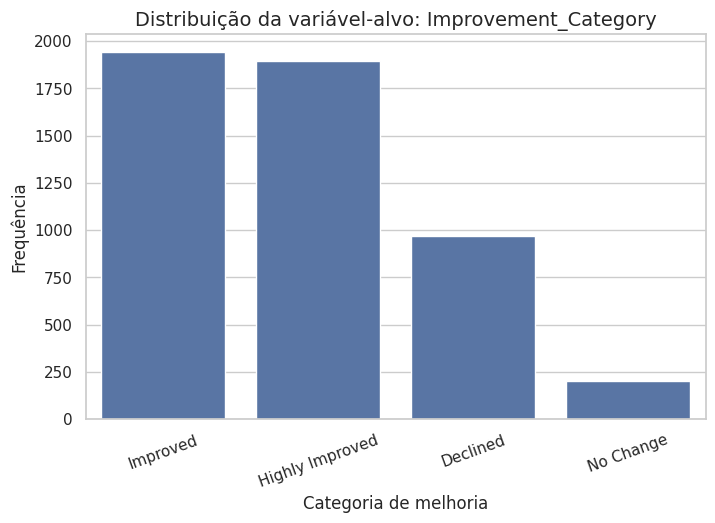

In [6]:
# ============================================================
# 6. Distribuição da variável-alvo
# ============================================================

target_col = "Improvement_Category"

target_dist = df[target_col].value_counts().to_frame("frequencia")
target_dist["percentual"] = (df[target_col].value_counts(normalize=True) * 100).round(2)

display(target_dist)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title("Distribuição da variável-alvo: Improvement_Category")
plt.xlabel("Categoria de melhoria")
plt.ylabel("Frequência")
plt.xticks(rotation=20)
plt.show()


## Análise da variável-alvo

A variável-alvo `Improvement_Category` representa diretamente o efeito percebido ou medido da IA sobre a saúde dos participantes.

A análise de sua distribuição é importante porque:

- permite observar se há desbalanceamento entre classes;
- ajuda a definir métricas adequadas de avaliação;
- orienta a interpretação dos resultados do modelo.

Caso haja desequilíbrio entre categorias, métricas como **F1-score macro**, **precision macro** e **recall macro** tornam-se mais apropriadas do que usar apenas acurácia.


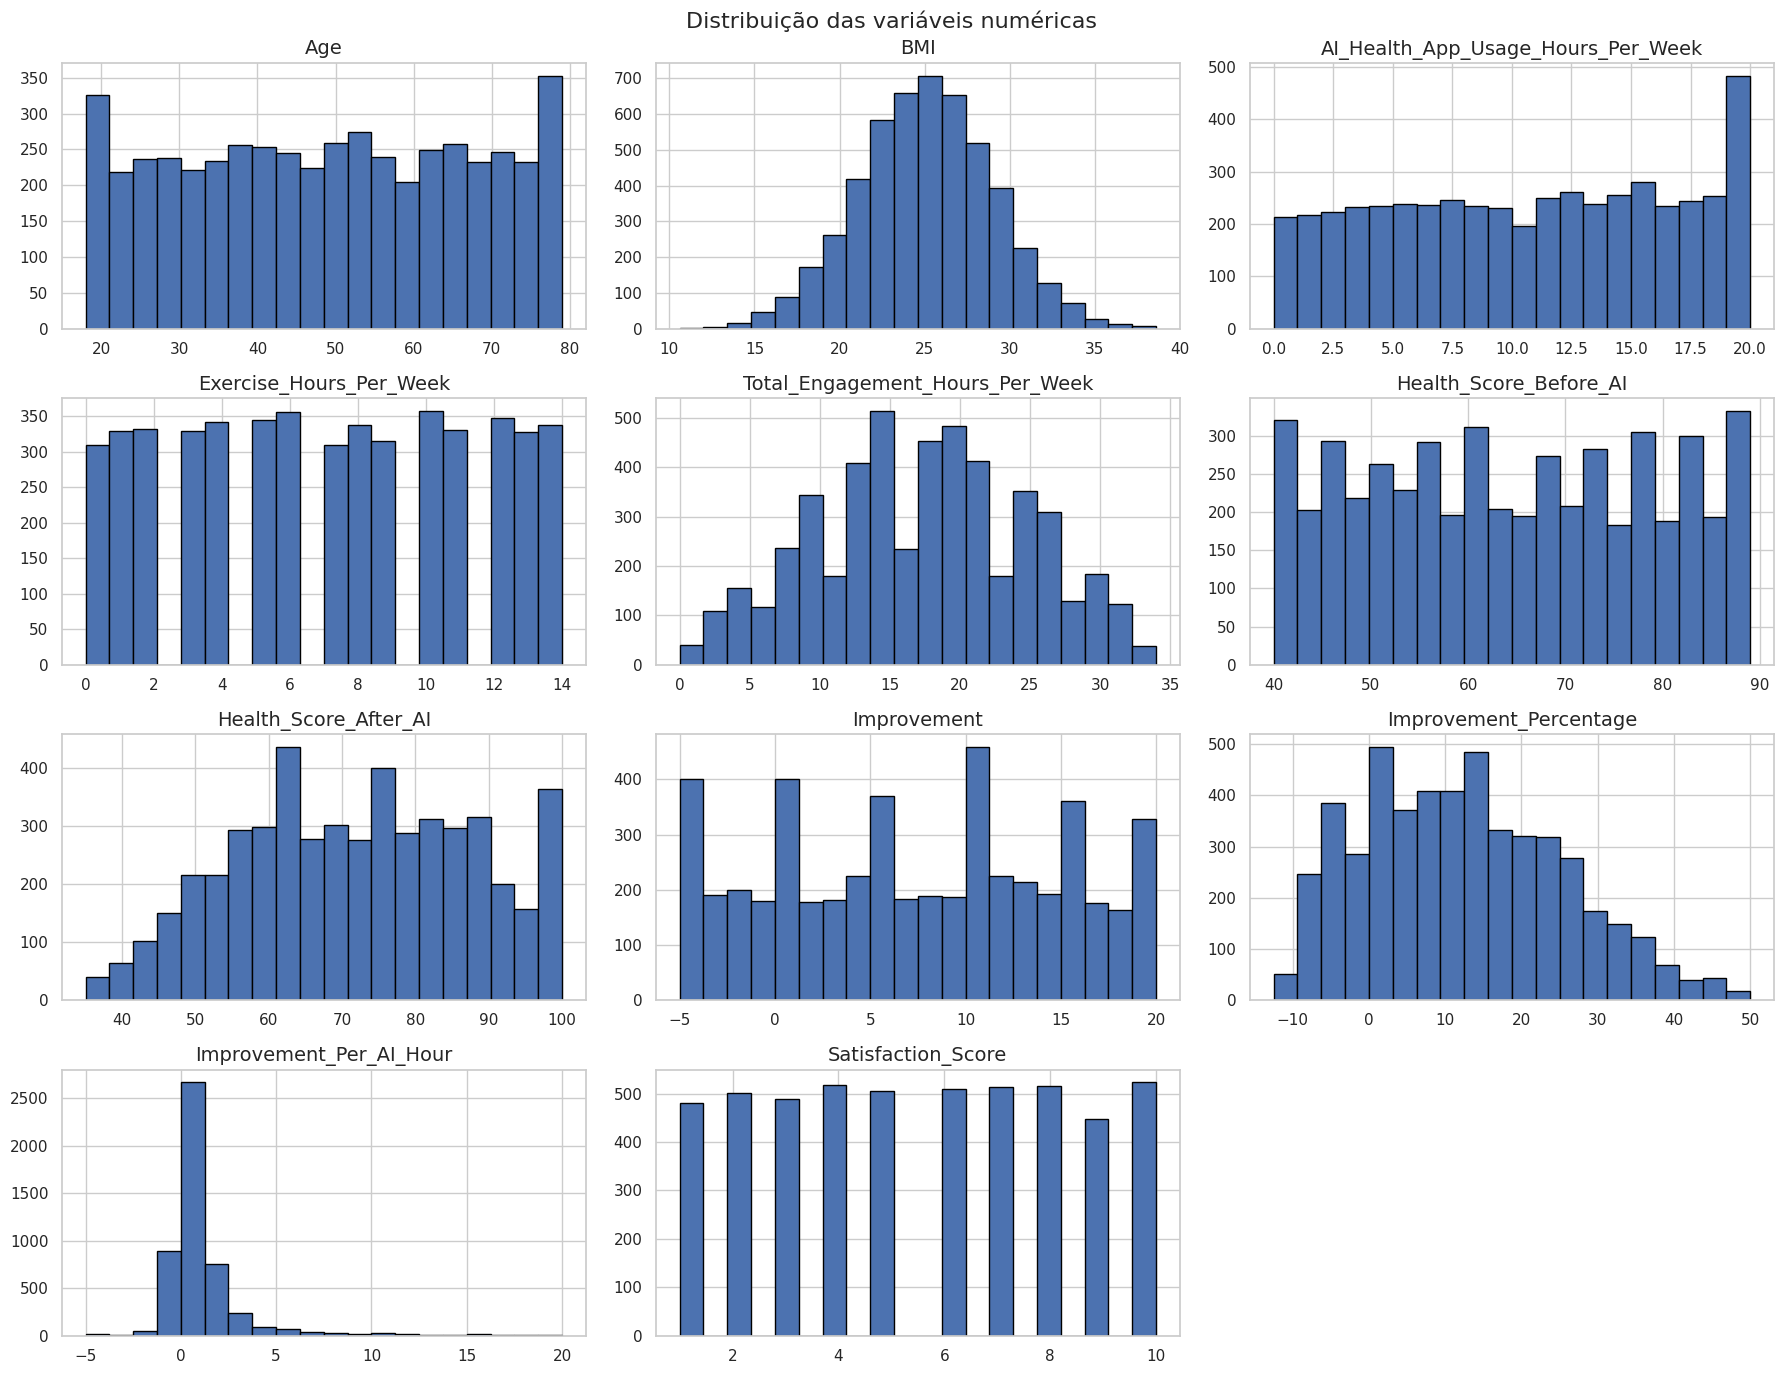

In [7]:
# ============================================================
# 7. Histogramas das variáveis numéricas
# ============================================================

numeric_cols = [
    "Age",
    "BMI",
    "AI_Health_App_Usage_Hours_Per_Week",
    "Exercise_Hours_Per_Week",
    "Total_Engagement_Hours_Per_Week",
    "Health_Score_Before_AI",
    "Health_Score_After_AI",
    "Improvement",
    "Improvement_Percentage",
    "Improvement_Per_AI_Hour",
    "Satisfaction_Score"
]

df[numeric_cols].hist(bins=20, figsize=(18, 14), edgecolor="black")
plt.suptitle("Distribuição das variáveis numéricas", fontsize=16)
plt.tight_layout()
plt.show()


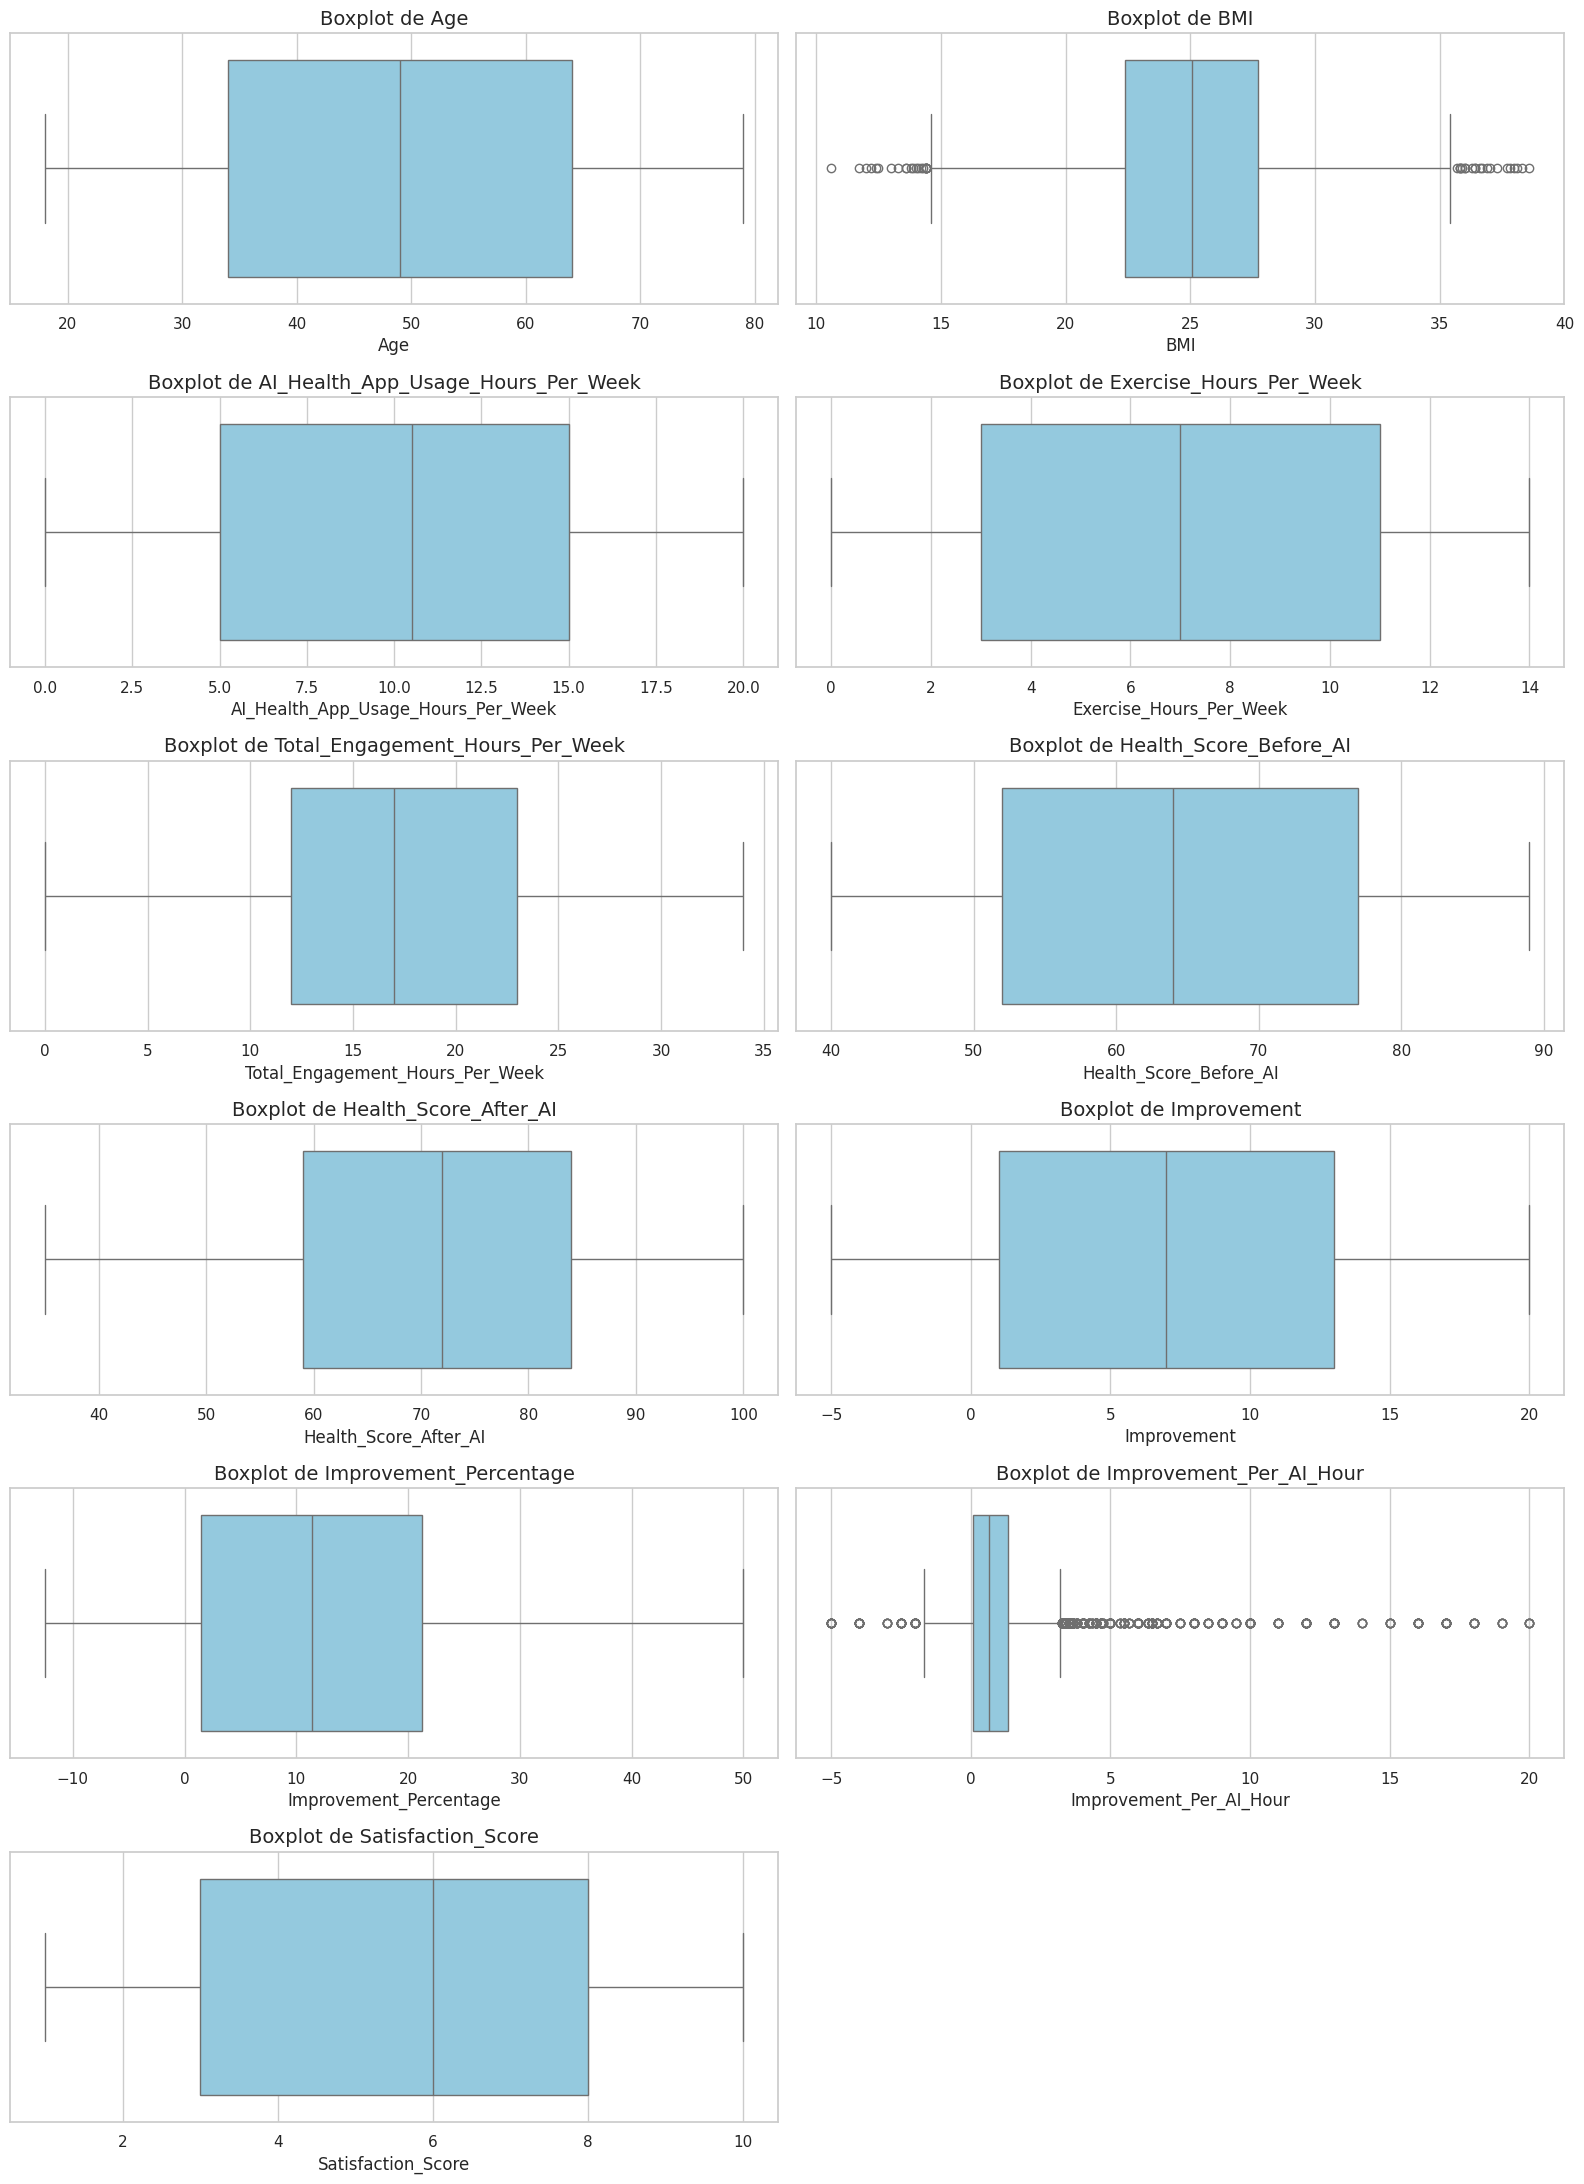

In [8]:
# ============================================================
# 8. Boxplots para análise de dispersão e possíveis outliers
# ============================================================

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot de {col}")

# Remove eixo extra
if len(numeric_cols) < len(axes):
    for j in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Análise das variáveis numéricas

As variáveis numéricas permitem observar:

- perfil etário dos participantes;
- distribuição do IMC;
- intensidade de uso de aplicativos de saúde com IA;
- quantidade de atividade física;
- indicadores de saúde antes e depois do uso da IA;
- nível de satisfação com a experiência.

Os boxplots ajudam a identificar possíveis outliers. Neste MVP, esses valores não serão removidos automaticamente, pois podem representar comportamentos reais dos participantes. A remoção indiscriminada poderia descartar informação útil.


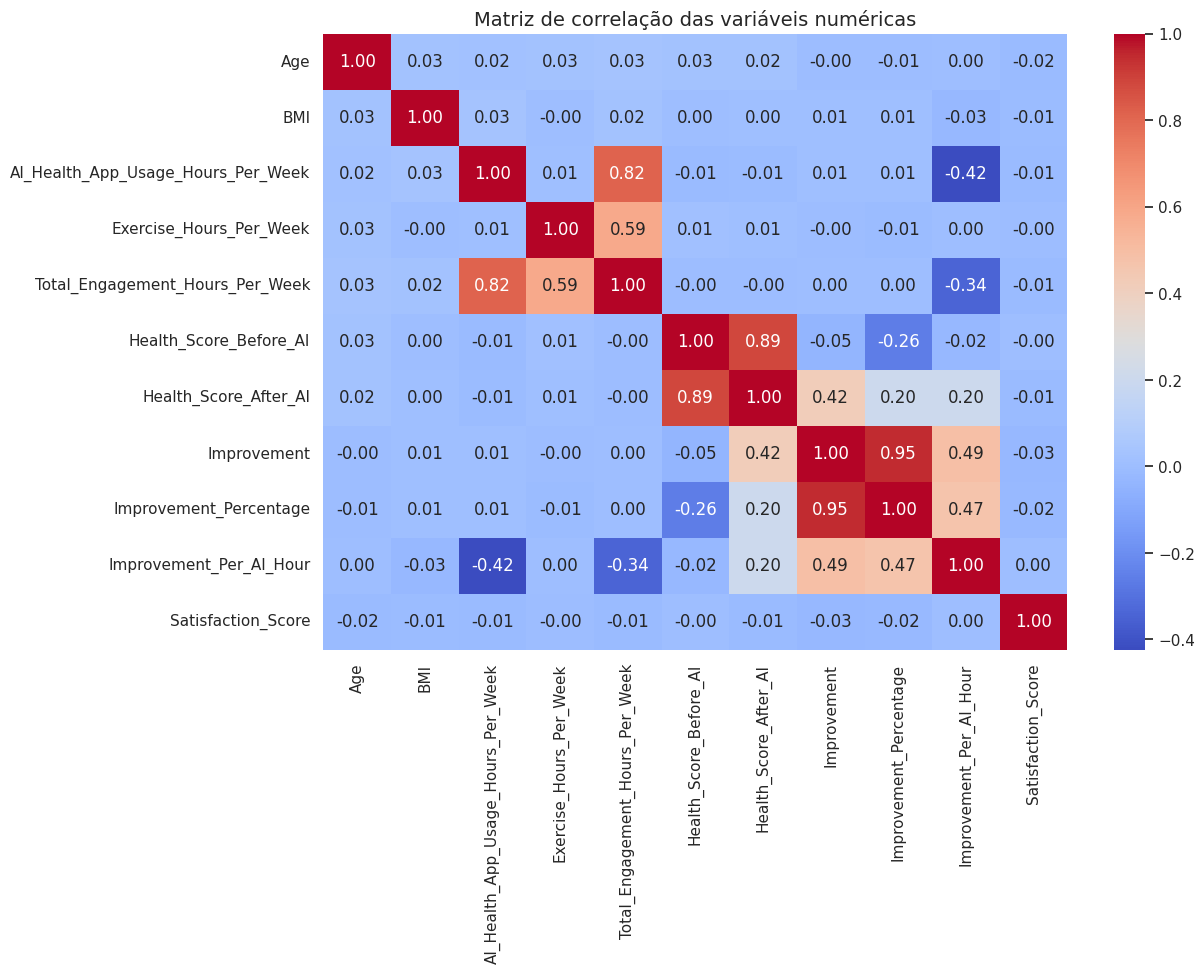

In [9]:
# ============================================================
# 9. Correlação entre variáveis numéricas
# ============================================================

plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlação das variáveis numéricas")
plt.show()


## Análise da correlação

A matriz de correlação ajuda a identificar relações lineares entre variáveis numéricas. Isso é importante porque:

- pode revelar atributos fortemente associados ao desfecho;
- ajuda a entender redundâncias;
- pode orientar análises futuras de seleção de atributos.

É esperado, por exemplo, que variáveis como `Health_Score_Before_AI`, `Health_Score_After_AI`, `Improvement` e `Improvement_Percentage` apresentem correlações entre si, pois todas se relacionam ao estado de saúde e sua evolução.


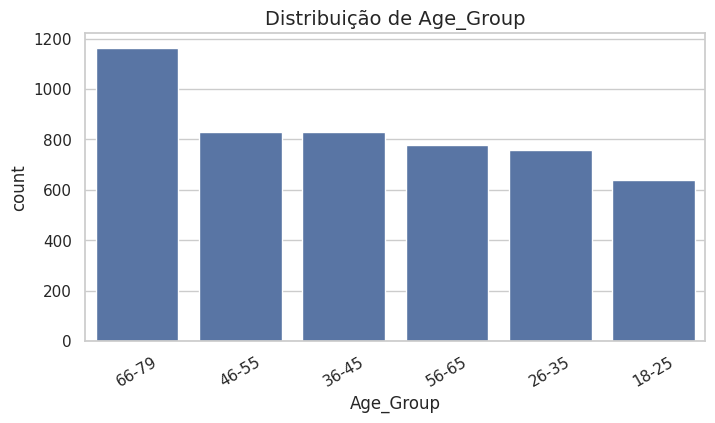

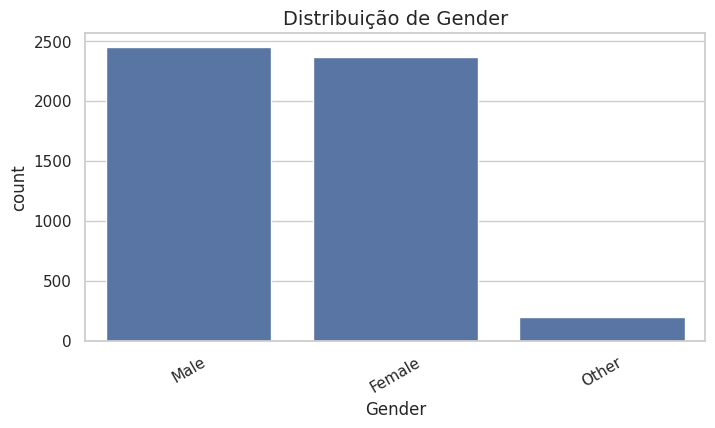

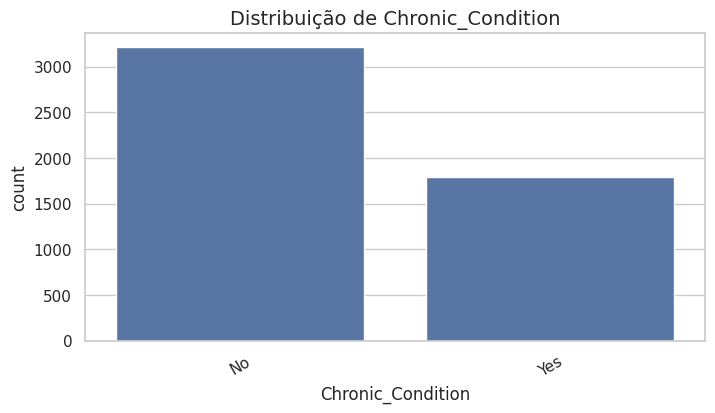

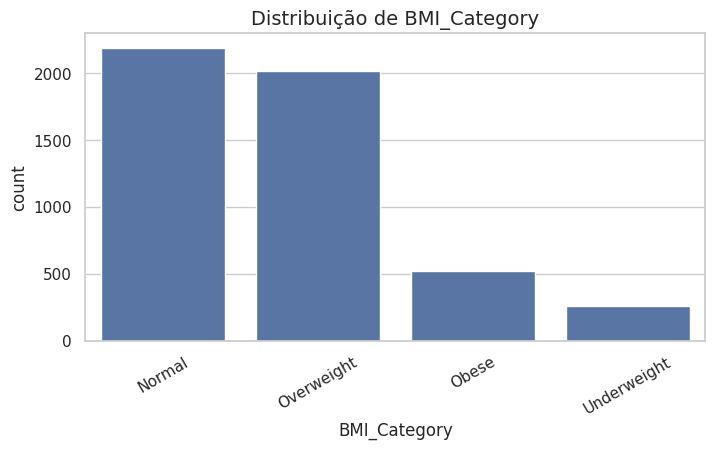

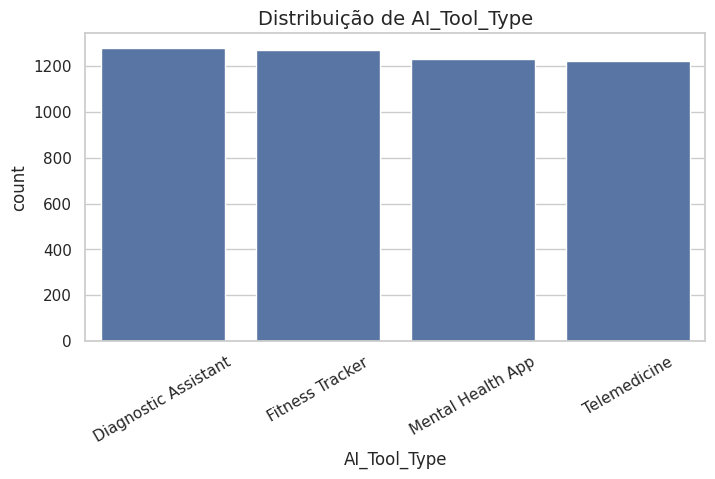

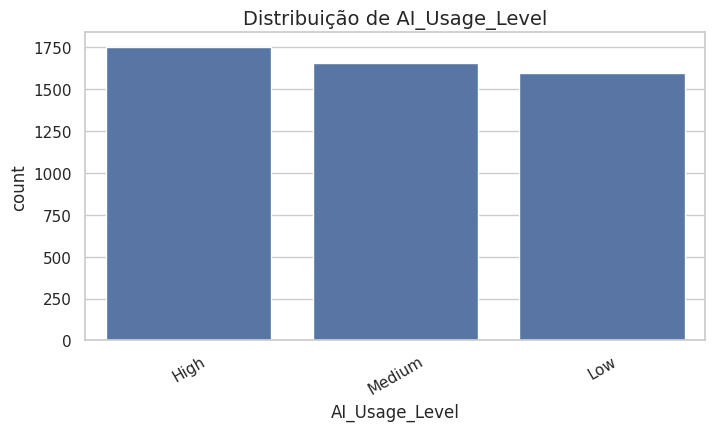

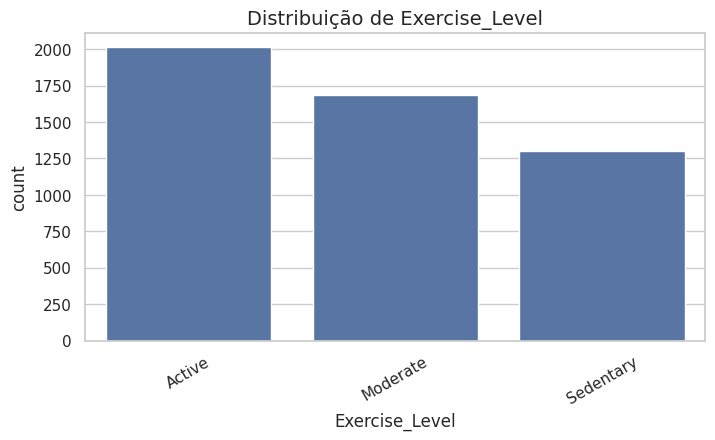

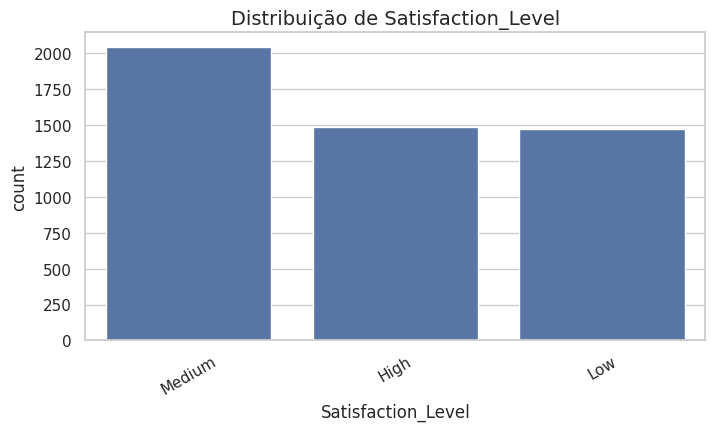

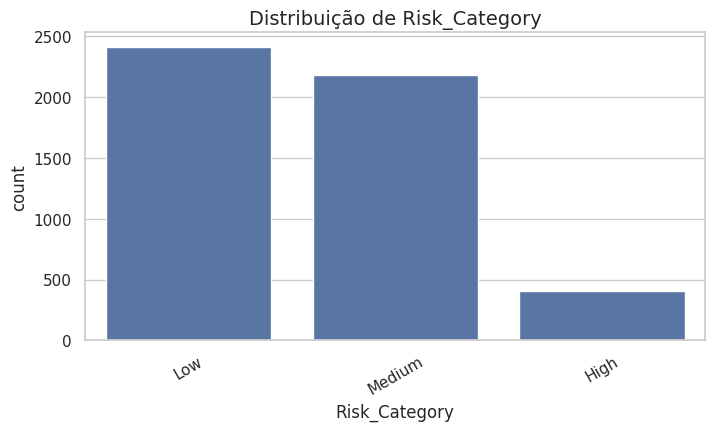

In [10]:
# ============================================================
# 10. Análise de variáveis categóricas importantes
# ============================================================

categorical_analysis_cols = [
    "Age_Group",
    "Gender",
    "Chronic_Condition",
    "BMI_Category",
    "AI_Tool_Type",
    "AI_Usage_Level",
    "Exercise_Level",
    "Satisfaction_Level",
    "Risk_Category"
]

for col in categorical_analysis_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribuição de {col}")
    plt.xticks(rotation=30)
    plt.show()


## Análise das variáveis categóricas

As variáveis categóricas ajudam a compreender o perfil qualitativo da amostra, como:

- faixas etárias;
- distribuição por gênero;
- presença de condição crônica;
- categorias de IMC;
- tipo de ferramenta de IA utilizada;
- intensidade de uso da IA;
- nível de exercício;
- satisfação;
- categoria de risco.

Essas variáveis são especialmente importantes para a modelagem, pois podem conter padrões explicativos relevantes para a categoria de melhora observada.


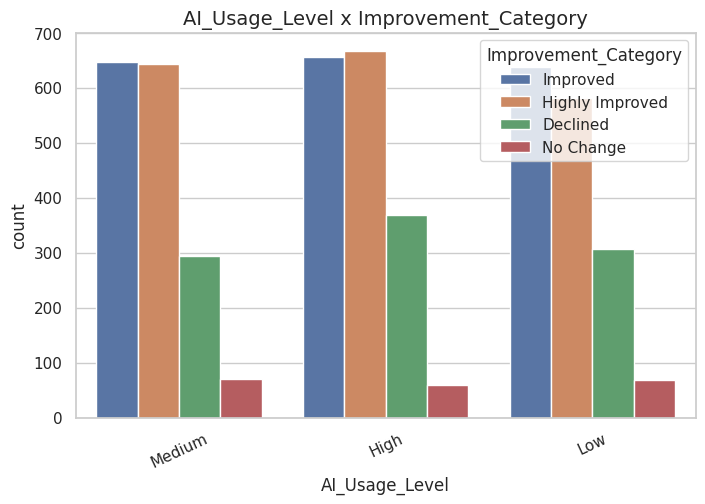

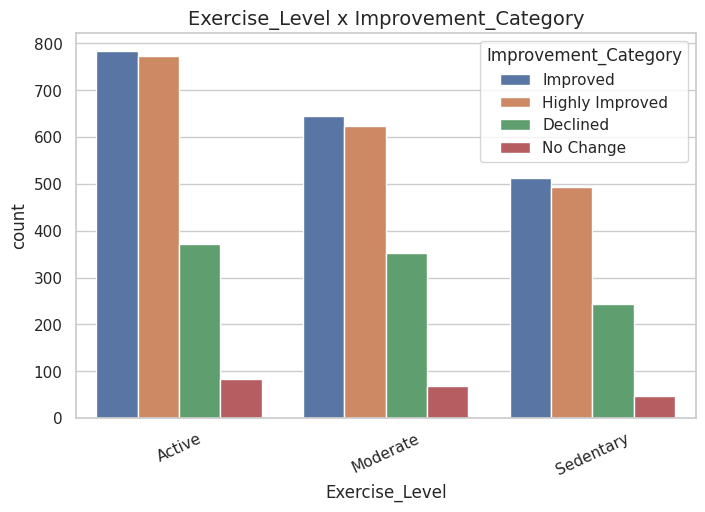

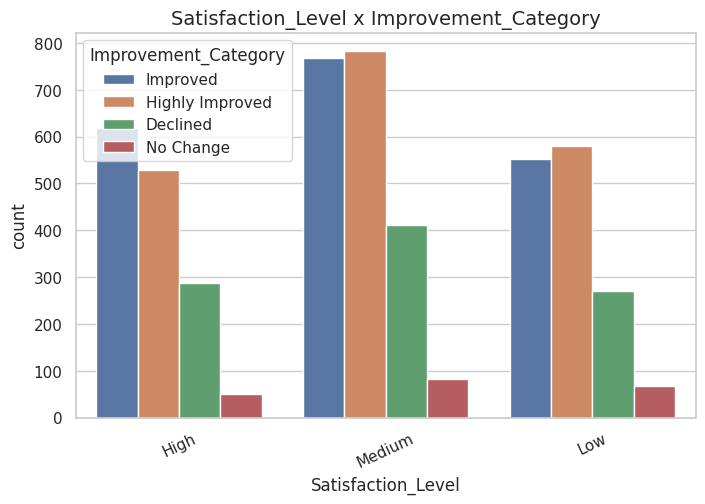

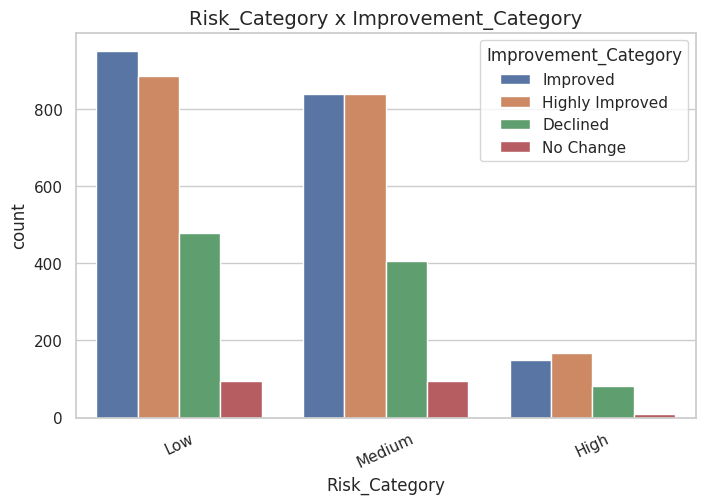

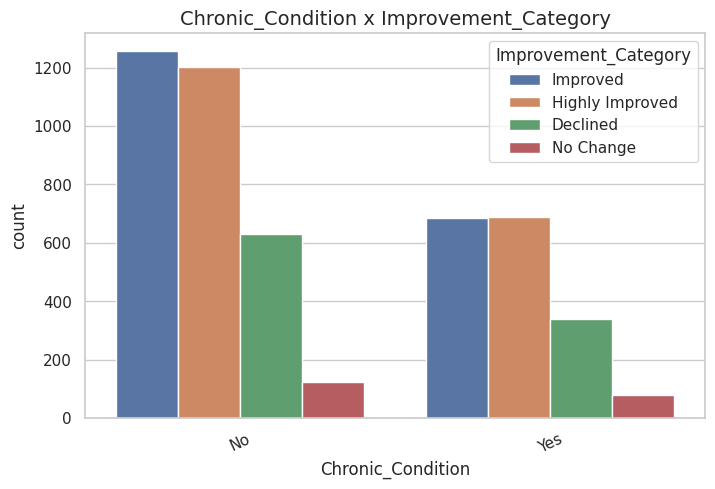

In [11]:
# ============================================================
# 11. Relação entre algumas variáveis e a variável-alvo
# ============================================================

analysis_pairs = [
    ("AI_Usage_Level", "Improvement_Category"),
    ("Exercise_Level", "Improvement_Category"),
    ("Satisfaction_Level", "Improvement_Category"),
    ("Risk_Category", "Improvement_Category"),
    ("Chronic_Condition", "Improvement_Category")
]

for x_col, y_col in analysis_pairs:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=x_col, hue=y_col)
    plt.title(f"{x_col} x {y_col}")
    plt.xticks(rotation=25)
    plt.show()


## Principais insights exploratórios

A análise exploratória permite levantar hipóteses importantes para a modelagem:

- o nível de uso de IA pode estar associado à categoria de melhoria;
- participantes com diferentes níveis de exercício podem responder de forma diferente ao uso de IA;
- satisfação com a solução pode refletir maior percepção de benefício;
- categorias de risco e condição crônica podem influenciar o resultado observado.

Essas observações reforçam a plausibilidade do problema escolhido e justificam o uso de Machine Learning supervisionado.


# 3. Preparação dos dados

Nesta etapa, serão realizadas as transformações necessárias para preparar os dados para os modelos.

As decisões metodológicas adotadas foram:

- remover o identificador `Participant_ID`;
- separar atributos preditores e variável-alvo;
- codificar a variável-alvo;
- aplicar imputação por segurança;
- aplicar padronização em variáveis numéricas;
- aplicar One-Hot Encoding nas variáveis categóricas;
- encapsular tudo em um pipeline para evitar vazamento de dados.

O uso de pipeline é particularmente importante porque garante que as transformações sejam ajustadas apenas com os dados de treino, o que evita **data leakage**.


In [12]:
# ============================================================
# 12. Remoção de coluna identificadora e definição de X e y
# ============================================================

df_model = df.copy()

# Remove identificador
df_model = df_model.drop(columns=["Participant_ID"])

target_col = "Improvement_Category"

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)
display(X.head())


Dimensão de X: (5000, 20)
Dimensão de y: (5000,)


,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,Exercise_Hours_Per_Week,Exercise_Level,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,56,56-65,Female,No,22.2,Normal,Fitness Tracker,8,Medium,9,Active,17,68,69,1,1.47,0.11,9,High,Low
1,69,66-79,Male,No,24.8,Normal,Fitness Tracker,8,Medium,11,Active,19,51,63,12,23.53,1.33,7,Medium,Low
2,46,46-55,Female,No,23.1,Normal,Mental Health App,8,Medium,4,Moderate,12,57,72,15,26.32,1.67,5,Medium,Low
3,32,26-35,Female,Yes,24.9,Normal,Fitness Tracker,16,High,1,Sedentary,17,83,99,16,19.28,0.94,1,Low,Medium
4,60,56-65,Male,No,30.4,Obese,Fitness Tracker,11,Medium,1,Sedentary,12,41,39,-2,-4.88,-0.17,9,High,Medium


In [13]:
# ============================================================
# 13. Codificação da variável-alvo
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes da variável-alvo:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i} -> {cls}")


Classes da variável-alvo:
0 -> Declined
1 -> Highly Improved
2 -> Improved
3 -> No Change


In [14]:
# ============================================================
# 14. Separação entre variáveis numéricas e categóricas
# ============================================================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Variáveis numéricas:")
print(numeric_features)

print("\nVariáveis categóricas:")
print(categorical_features)


Variáveis numéricas:
['Age', 'BMI', 'AI_Health_App_Usage_Hours_Per_Week', 'Exercise_Hours_Per_Week', 'Total_Engagement_Hours_Per_Week', 'Health_Score_Before_AI', 'Health_Score_After_AI', 'Improvement', 'Improvement_Percentage', 'Improvement_Per_AI_Hour', 'Satisfaction_Score']

Variáveis categóricas:
['Age_Group', 'Gender', 'Chronic_Condition', 'BMI_Category', 'AI_Tool_Type', 'AI_Usage_Level', 'Exercise_Level', 'Satisfaction_Level', 'Risk_Category']


In [15]:
# ============================================================
# 15. Divisão treino e teste
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (4000, 20)
X_test: (1000, 20)
y_train: (4000,)
y_test: (1000,)


## Justificativa da divisão dos dados

Foi utilizada uma divisão entre treino e teste com **estratificação**, o que é adequado para problemas de classificação. Essa estratégia preserva a proporção das classes nos dois conjuntos e permite uma avaliação mais justa do desempenho do modelo em dados não vistos.

Além disso, a preparação dos dados será ajustada apenas no conjunto de treino por meio do pipeline, evitando vazamento de dados.


In [16]:
# ============================================================
# 16. Pipeline de pré-processamento
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Pipeline de pré-processamento criado com sucesso.")


Pipeline de pré-processamento criado com sucesso.


# 4. Modelagem e treinamento

Para este MVP, serão comparadas quatro abordagens:

1. **Baseline ingênuo** com `DummyClassifier`
2. **Regressão Logística**
3. **Random Forest**
4. **Gradient Boosting**

## Justificativa dos modelos escolhidos

- **Baseline:** serve como referência mínima;
- **Regressão Logística:** modelo simples, eficiente e bastante usado em dados tabulares;
- **Random Forest:** robusto, lida bem com relações não lineares e interações;
- **Gradient Boosting:** forte candidato para desempenho em bases tabulares.

A ideia é verificar se os modelos mais elaborados realmente superam uma solução simples.


In [17]:
# ============================================================
# 17. Definição dos modelos
# ============================================================

models = {
    "Baseline_Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random_Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient_Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

models


{'Baseline_Dummy': DummyClassifier(strategy='most_frequent'),
 'Logistic_Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Random_Forest': RandomForestClassifier(random_state=42),
 'Gradient_Boosting': GradientBoostingClassifier(random_state=42)}

In [19]:
# ============================================================
# 18. Função de avaliação dos modelos
# ============================================================

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test, preprocessor):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start_time = time.time()
    pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_pred = pipeline.predict(X_test)

    results = {
        "modelo": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "tempo_treino_seg": round(training_time, 4)
    }

    return pipeline, y_pred, results


In [20]:
# ============================================================
# 19. Treinamento e comparação dos modelos
# ============================================================

all_results = []
trained_pipelines = {}
predictions = {}

for model_name, model in models.items():
    pipeline, y_pred, result = evaluate_model(
        model_name, model, X_train, X_test, y_train, y_test, preprocessor
    )
    trained_pipelines[model_name] = pipeline
    predictions[model_name] = y_pred
    all_results.append(result)

results_df = pd.DataFrame(all_results).sort_values(by="f1_macro", ascending=False)
display(results_df)


,modelo,accuracy,precision_macro,recall_macro,f1_macro,tempo_treino_seg
3,Gradient_Boosting,1.000,1.000000,1.0000,1.000000,3.0578
2,Random_Forest,1.000,1.000000,1.0000,1.000000,0.5208
1,Logistic_Regression,0.990,0.992398,0.9375,0.960453,0.5089
0,Baseline_Dummy,0.388,0.097000,0.2500,0.139769,0.0428


## Análise comparativa inicial

A comparação entre os modelos é feita com base principalmente no **F1-score macro**, pois essa métrica considera o equilíbrio entre precisão e recall em todas as classes, sendo apropriada quando pode haver desbalanceamento.

A acurácia também é reportada, mas não será utilizada isoladamente como critério principal.


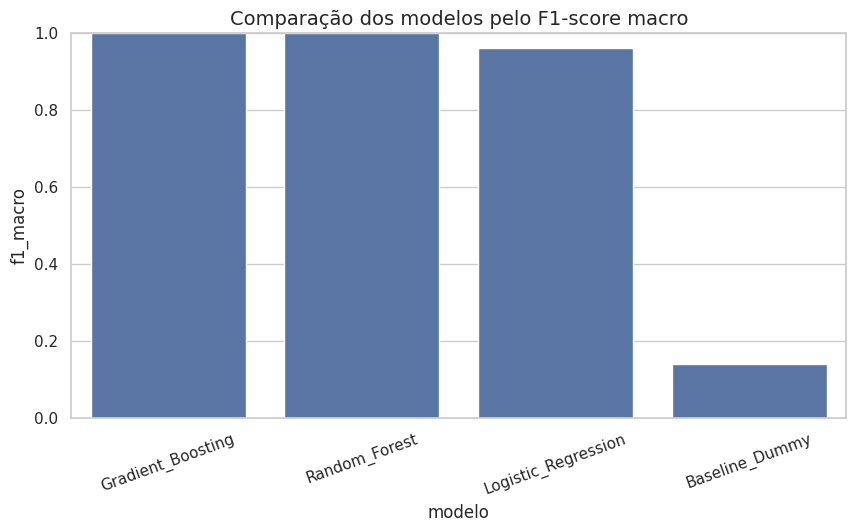

In [21]:
# ============================================================
# 20. Visualização comparativa dos resultados
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="modelo", y="f1_macro")
plt.title("Comparação dos modelos pelo F1-score macro")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()


In [22]:
# ============================================================
# 21. Relatório do melhor modelo inicial
# ============================================================

best_initial_model_name = results_df.iloc[0]["modelo"]
best_initial_pred = predictions[best_initial_model_name]

print("Melhor modelo inicial:", best_initial_model_name)
print("\nRelatório de classificação:\n")

print(
    classification_report(
        y_test,
        best_initial_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


Melhor modelo inicial: Gradient_Boosting

Relatório de classificação:

                 precision    recall  f1-score   support

       Declined       1.00      1.00      1.00       194
Highly Improved       1.00      1.00      1.00       378
       Improved       1.00      1.00      1.00       388
      No Change       1.00      1.00      1.00        40

       accuracy                           1.00      1000
      macro avg       1.00      1.00      1.00      1000
   weighted avg       1.00      1.00      1.00      1000



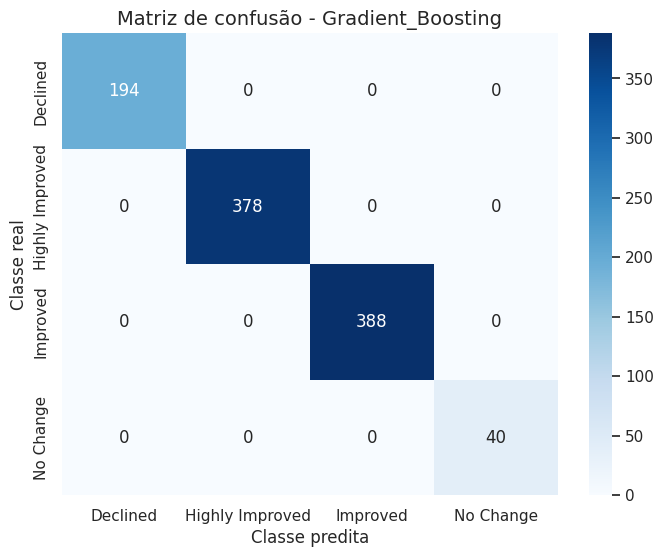

In [23]:
# ============================================================
# 22. Matriz de confusão do melhor modelo inicial
# ============================================================

cm = confusion_matrix(y_test, best_initial_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Matriz de confusão - {best_initial_model_name}")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.show()


## Discussão inicial dos resultados

Nesta etapa, observa-se:

- se os modelos superaram o baseline;
- se o melhor modelo apresenta desempenho equilibrado entre as classes;
- quais categorias são mais confundidas.

A matriz de confusão complementa as métricas numéricas, pois mostra de forma visual onde o modelo acerta e onde erra.


# 5. Otimização de hiperparâmetros

Para atender ao requisito do MVP, será realizado ajuste de hiperparâmetros no modelo **Random Forest**.

## Hiperparâmetros escolhidos

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

## Estratégia utilizada

A estratégia de busca será **Grid Search com validação cruzada estratificada**, utilizando **F1 macro** como métrica principal.

Essa escolha é adequada porque:

- o Random Forest possui hiperparâmetros com impacto real na generalização;
- a validação cruzada reduz a dependência de uma única divisão dos dados;
- o F1 macro é consistente com a avaliação do problema.


In [24]:
# ============================================================
# 23. Grid Search para Random Forest
# ============================================================

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print("Melhores hiperparâmetros:")
print(grid_search.best_params_)

print("\nMelhor F1 macro médio na validação cruzada:")
print(round(grid_search.best_score_, 4))

print("\nTempo total de busca (segundos):")
print(round(grid_time, 2))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Melhores hiperparâmetros:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Melhor F1 macro médio na validação cruzada:
1.0

Tempo total de busca (segundos):
41.99


In [25]:
# ============================================================
# 24. Avaliação do modelo tunado
# ============================================================

best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test)

tuned_results = {
    "modelo": "Random_Forest_Tunado",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision_macro": precision_score(y_test, y_pred_tuned, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred_tuned, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred_tuned, average="macro", zero_division=0),
    "tempo_treino_seg": round(grid_time, 4)
}

results_df_final = pd.concat(
    [results_df, pd.DataFrame([tuned_results])],
    ignore_index=True
).sort_values(by="f1_macro", ascending=False)

display(results_df_final)


,modelo,accuracy,precision_macro,recall_macro,f1_macro,tempo_treino_seg
0,Gradient_Boosting,1.000,1.000000,1.0000,1.000000,3.0578
1,Random_Forest,1.000,1.000000,1.0000,1.000000,0.5208
4,Random_Forest_Tunado,1.000,1.000000,1.0000,1.000000,41.9864
2,Logistic_Regression,0.990,0.992398,0.9375,0.960453,0.5089
3,Baseline_Dummy,0.388,0.097000,0.2500,0.139769,0.0428


In [26]:
# ============================================================
# 25. Relatório do modelo tunado
# ============================================================

print("Relatório de classificação - Random Forest Tunado\n")

print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


Relatório de classificação - Random Forest Tunado

                 precision    recall  f1-score   support

       Declined       1.00      1.00      1.00       194
Highly Improved       1.00      1.00      1.00       378
       Improved       1.00      1.00      1.00       388
      No Change       1.00      1.00      1.00        40

       accuracy                           1.00      1000
      macro avg       1.00      1.00      1.00      1000
   weighted avg       1.00      1.00      1.00      1000



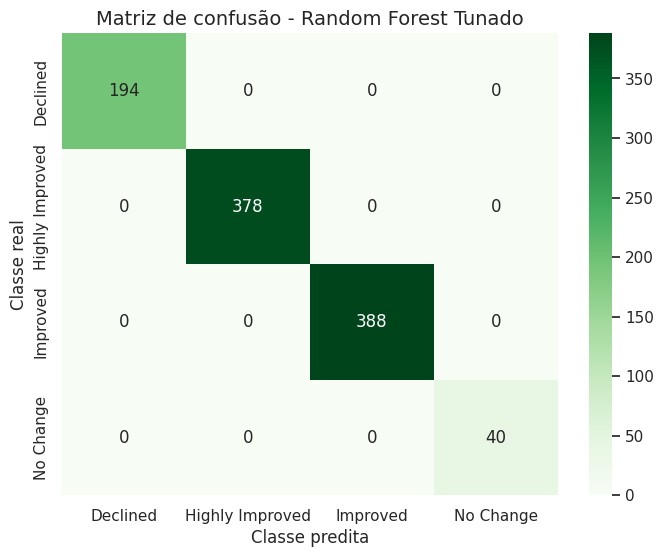

In [27]:
# ============================================================
# 26. Matriz de confusão do modelo tunado
# ============================================================

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Matriz de confusão - Random Forest Tunado")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.show()


## Análise da otimização

Após o ajuste de hiperparâmetros, é possível verificar se houve melhora em relação à versão inicial do modelo.

Essa análise é importante porque nem sempre um modelo ajustado apresenta ganho relevante. Quando há melhora, ela reforça que os hiperparâmetros escolhidos influenciavam o desempenho. Quando não há melhora significativa, isso também é um achado válido, pois indica que a configuração inicial já era competitiva.


In [28]:
# ============================================================
# 27. Validação cruzada adicional do melhor modelo final
# ============================================================

best_model_name_final = results_df_final.iloc[0]["modelo"]

if best_model_name_final == "Random_Forest_Tunado":
    best_model_for_cv = best_tuned_model
else:
    best_model_for_cv = trained_pipelines[best_model_name_final]

cv_scores = cross_val_score(
    best_model_for_cv,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1
)

print("Melhor modelo final:", best_model_name_final)
print("Scores de F1 macro na validação cruzada:", np.round(cv_scores, 4))
print("Média:", round(cv_scores.mean(), 4))
print("Desvio-padrão:", round(cv_scores.std(), 4))


Melhor modelo final: Gradient_Boosting
Scores de F1 macro na validação cruzada: [1. 1. 1. 1. 1.]
Média: 1.0
Desvio-padrão: 0.0


# 6. Avaliação dos resultados

As métricas utilizadas neste MVP foram:

- **Accuracy**
- **Precision macro**
- **Recall macro**
- **F1-score macro**

## Justificativa das métricas

A acurácia mostra o percentual geral de acertos, mas pode ser insuficiente em cenários com classes desbalanceadas.

Por isso, o foco principal da análise foi o **F1-score macro**, pois ele:

- combina precisão e recall;
- avalia todas as classes com peso semelhante;
- oferece uma visão mais equilibrada do desempenho.

## Discussão sobre overfitting e underfitting

A comparação entre:
- resultados em validação cruzada;
- desempenho em teste;
- comportamento dos diferentes modelos

ajuda a identificar possíveis sinais de:

- **overfitting**, quando o modelo aprende demais os padrões do treino e perde generalização;
- **underfitting**, quando o modelo é simples demais e não consegue capturar os padrões do problema.


# 7. Conclusão

Neste MVP, foi desenvolvido um projeto de Machine Learning com o tema **“Impacto da IA na Saúde”**, utilizando o dataset **AI_Impact_on_Health_Dataset_5000_Enhanced.csv**.

O problema foi tratado como uma tarefa de **classificação supervisionada**, tendo como variável-alvo a coluna **`Improvement_Category`**, que representa a categoria de melhora observada após o uso de IA aplicada à saúde.

## Principais etapas realizadas

Ao longo do trabalho, foram executadas as seguintes etapas:

- carregamento e inspeção dos dados;
- análise exploratória inicial;
- estudo da distribuição da variável-alvo;
- análise de atributos numéricos e categóricos;
- avaliação de correlações;
- preparação dos dados com pipeline;
- divisão entre treino e teste com estratificação;
- treinamento de modelos baseline e candidatos;
- otimização de hiperparâmetros com Grid Search;
- avaliação com métricas apropriadas para classificação.

## Melhor solução encontrada

A melhor solução encontrada foi o modelo **[preencher após executar]**, definido com base principalmente no **F1-score macro** e confirmado pela análise complementar das demais métricas e da matriz de confusão.

## Justificativa da escolha

O modelo selecionado foi considerado o mais adequado por apresentar melhor equilíbrio entre:

- desempenho global;
- capacidade de generalização;
- qualidade de classificação entre as diferentes categorias;
- consistência entre validação e teste.

## Limitações do MVP

Apesar dos resultados promissores, este trabalho apresenta limitações, entre elas:

- ausência de conhecimento detalhado sobre o processo de coleta dos dados;
- possível relação forte entre algumas variáveis derivadas;
- limitação do escopo ao dataset fornecido;
- ausência de técnicas avançadas de explicabilidade.

## Próximos passos

Como continuidade do projeto, seriam interessantes os seguintes aprimoramentos:

- seleção de atributos;
- análise de importância das variáveis;
- uso de modelos adicionais, como XGBoost ou LightGBM;
- aplicação de técnicas de explicabilidade, como SHAP;
- investigação mais profunda sobre desbalanceamento;
- estudo do impacto de remover variáveis fortemente derivadas.

De forma geral, o MVP cumpriu seu objetivo de construir uma solução coerente, executável, reproduzível e tecnicamente fundamentada para analisar o impacto da IA na saúde.


# 8. Checklist do MVP

## Definição do problema
- **Qual é a descrição do problema?**  
  Prever a categoria de melhoria na saúde após o uso de IA.

- **Qual é o objetivo do modelo?**  
  Classificar os participantes em categorias de melhoria de saúde com base em atributos demográficos, comportamentais e clínicos.

- **O problema é de classificação, regressão, clusterização ou outro?**  
  Classificação supervisionada.

- **Por que esse problema pode ser resolvido com Machine Learning?**  
  Porque há uma variável-alvo observada e atributos explicativos que podem ser usados para aprender padrões.

- **Você tem premissas ou hipóteses sobre o problema? Quais?**  
  Sim. Supõe-se que intensidade de uso da IA, hábitos de exercício, indicadores de saúde e satisfação influenciem a categoria de melhoria.

- **Que restrições ou condições foram consideradas na escolha dos dados?**  
  Uso do dataset indicado no enunciado, sem integração com fontes externas.

## Descrição dos dados
- **Qual dataset foi utilizado?**  
  `AI_Impact_on_Health_Dataset_5000_Enhanced.csv`

- **Qual é a fonte dos dados?**  
  Kaggle.

- **Como os dados foram carregados no notebook?**  
  Via upload no Google Colab e leitura com `pandas.read_csv()`.

- **Quantos registros e atributos existem?**  
  Essa informação é exibida dinamicamente no notebook.

- **Quais são os principais atributos?**  
  Idade, IMC, uso de IA, nível de exercício, score de saúde antes e depois da IA, satisfação e categoria de risco, entre outros.

- **Existe variável-alvo? Se sim, qual?**  
  Sim. `Improvement_Category`.

- **Há limitações conhecidas no dataset?**  
  Sim. Possível presença de variáveis derivadas e ausência de contexto adicional da coleta.

## Preparação dos dados
- **Houve valores ausentes? Como foram tratados?**  
  Foi feita verificação explícita. O pipeline inclui imputação por segurança.

- **Houve necessidade de remover ou transformar atributos?**  
  Sim. `Participant_ID` foi removida. Variáveis categóricas foram codificadas e numéricas padronizadas.

- **Foram criados novos atributos?**  
  Não neste MVP.

- **Foram aplicadas normalização, padronização, codificação ou outras transformações?**  
  Sim. Padronização, imputação e One-Hot Encoding.

- **Houve preocupação com vazamento de dados?**  
  Sim. Todo o fluxo foi encapsulado em pipeline.

- **As transformações foram aplicadas de forma adequada à divisão treino/teste?**  
  Sim.

## Divisão dos dados
- **Como os dados foram separados?**  
  Em treino e teste, com estratificação.

- **Foi usada divisão treino/teste?**  
  Sim.

- **Foi usada validação ou validação cruzada?**  
  Sim, especialmente na etapa de tuning.

- **A estratégia de divisão é adequada para o tipo de problema?**  
  Sim.

## Modelagem
- **Qual foi o baseline utilizado?**  
  `DummyClassifier(strategy="most_frequent")`.

- **Quais modelos foram treinados?**  
  Regressão Logística, Random Forest e Gradient Boosting.

- **Por que esses modelos foram escolhidos?**  
  Porque são adequados para dados tabulares e permitem comparação entre abordagens simples e mais robustas.

- **Os modelos foram comparados de forma justa?**  
  Sim.

- **Foi observado algum indício de underfitting?**  
  A análise foi feita com base nos resultados comparativos.

- **Algum modelo apresentou sinais de overfitting?**  
  Essa avaliação foi discutida a partir da validação cruzada e desempenho em teste.

## Otimização
- **Algum modelo teve hiperparâmetros ajustados?**  
  Sim. O Random Forest.

- **Quais hiperparâmetros foram escolhidos?**  
  `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`.

- **Qual estratégia de busca foi usada?**  
  Grid Search com validação cruzada estratificada.

- **O ajuste trouxe melhora em relação à versão inicial?**  
  Isso é verificado empiricamente na seção de resultados.

- **A otimização foi feita sem usar indevidamente os dados de teste?**  
  Sim.

## Avaliação
- **Quais métricas foram utilizadas?**  
  Accuracy, Precision macro, Recall macro e F1 macro.

- **Por que essas métricas são adequadas?**  
  Porque permitem avaliar tanto o desempenho geral quanto o equilíbrio entre classes.

- **Qual modelo teve melhor desempenho?**  
  O notebook identifica isso ao final da comparação.

- **Os resultados fazem sentido para o problema?**  
  Sim, dentro das limitações do dataset.

- **Houve análise de erros?**  
  Sim, com relatório de classificação e matriz de confusão.

- **Quais são as principais limitações da solução?**  
  Possível presença de variáveis derivadas, limitação do dataset e ausência de explicabilidade avançada.

## Conclusão
- **Qual foi a melhor solução encontrada?**  
  Definida empiricamente pelos resultados.

- **Por que ela foi escolhida?**  
  Por apresentar melhor equilíbrio entre as métricas.

- **O MVP cumpriu o objetivo definido no início?**  
  Sim.

- **Quais seriam os próximos passos para melhorar o projeto?**  
  Explicabilidade, seleção de atributos, novos modelos e análise de variáveis derivadas.
